# Trabalho de Inteligência Artificial - CNN para GTSRB

## Comparando Arquiteturas

### 1. Setup

In [26]:
#!/usr/bin/env python3
import os
import json
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as T
from torch.utils.data import DataLoader, random_split
import seaborn as sns
import matplotlib.pyplot as plt
from typing import Optional
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model_pth_path = '/content/models_pth'
if not os.path.exists(model_pth_path):
  os.mkdir(model_pth_path)

figs_path = '/content/figs'
if not os.path.exists(figs_path):
    os.mkdir(figs_path)

checkpoints_path = '/content/checkpoints'
if not os.path.exists(checkpoints_path):
    os.mkdir(checkpoints_path)

from src.gtsrb import NUM_CLASSES, GTSRB_CLASSES, get_dataloaders, save_predictions

Using device: cuda


### 2. Funções de treino e avaliação

In [3]:
def train(trainloader,model,criterion,optimizer,device) -> tuple[float,float]:
    total_loss,correct,total  = 0.0, 0, 0

    for images, labels in trainloader:
      images, labels = images.to(device), labels.to(device)

      optimizer.zero_grad()
      outputs = model(images)
      loss = criterion(outputs, labels)
      loss.backward()
      optimizer.step()

      total_loss += loss.item() * images.size(0)
      correct += (outputs.argmax(dim=1) == labels).sum().item()
      total += labels.size(0)

    return total_loss/total, correct/total

def validate(val_loader,model,criterion,device) -> tuple[float,float]:
  total_loss,correct,total  = 0.0, 0, 0

  with torch.no_grad():
    for images, labels in val_loader:
      images, labels = images.to(device), labels.to(device)

      outputs = model(images)
      loss = criterion(outputs, labels)

      total_loss += loss.item() * images.size(0)
      correct += (outputs.argmax(dim=1) == labels).sum().item()
      total += labels.size(0)

  return total_loss/total, correct/total

def predict(loader,model,device):
    ytrue, ypred = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            pred = model(images).argmax(1).cpu().numpy()
            ytrue.append(labels.numpy())
            ypred.append(pred)

    ytrue = np.concatenate(ytrue)
    ypred = np.concatenate(ypred)

    return ytrue, ypred

def get_confusion_matrix(loader,model,device,num_class=43) -> torch.Tensor:
  cm = torch.zeros(NUM_CLASSES, NUM_CLASSES, dtype=torch.int64)

  with torch.no_grad():
      for images, labels in loader:
          images, labels = images.to(device), labels.to(device)
          outputs = model(images)
          _, predicted = torch.max(outputs.data, 1)
          for t, p in zip(labels, predicted):
              cm[t, p] += 1
  return cm

def per_class_accuracy(y_true, y_pred, num_classes=43) -> torch.Tensor:
    accs = torch.zeros(num_classes)
    for c in range(num_classes):
        mask = (y_true == c)
        total = float(mask.sum())
        if total > 0:
            accs[c] = float((y_pred[mask] == c).sum()) / total
        else:
            accs[c] = float('nan')
    return accs

### 3. Funções de salvamento e carregamento de modelos

In [4]:
def save_model(model,file_name,path=f'{model_pth_path}'):
  PATH = f'{path}/{file_name}'
  torch.save(model.state_dict(),PATH)
  return PATH

def load_model(file_name,path=f'{model_pth_path}'):
  PATH = f'{path}/{file_name}'
  model = SmallVGGNet()
  model.load_state_dict(torch.load(PATH))
  return model

### 4. Carregando Dados

In [ ]:
IMG_SIZE = 48
BATCH_SIZE = 128
NUM_EPOCHS = 40

train_loader, val_loader, test_loader = get_dataloaders(img_size=IMG_SIZE, batch_size=BATCH_SIZE)

100%|██████████| 187M/187M [00:03<00:00, 57.4MB/s]
100%|██████████| 89.0M/89.0M [00:00<00:00, 89.2MB/s]
100%|██████████| 99.6k/99.6k [00:00<00:00, 1.36MB/s]


### 4 . Baseline

In [6]:
# Classe do Modelo
class EHMNet(nn.Module):
  def __init__(self, num_classes:int = 43, img_size:int = 32):
    super(EHMNet,self).__init__()
    self.conv1 = nn.Conv2d(in_channels=3,out_channels=32,kernel_size=3,stride=1,padding='same')
    self.pool1 = nn.MaxPool2d(kernel_size=2,stride=2)
    self.conv2 = nn.Conv2d(in_channels=32,out_channels=64,kernel_size=3,stride=1,padding='same')
    self.pool2 = nn.MaxPool2d(kernel_size=2,stride=2)

    spatial = img_size // 4
    flatten_size = 64 * spatial * spatial
    self.fc1 = nn.Linear(in_features=flatten_size,out_features=256)
    self.fc2 = nn.Linear(in_features=256,out_features=num_classes)

  def forward(self,x):
    x = self.conv1(x)
    x = torch.relu(x)
    x = self.pool1(x)

    x = self.conv2(x)
    x = torch.relu(x)
    x = self.pool2(x)

    x = torch.flatten(x,1)

    x = self.fc1(x)
    x = torch.relu(x)
    x = self.fc2(x)

    return x

### 6. Criando Classe Baseline com Batch Normalization

In [19]:
class EHMNet_BN(nn.Module):
    def __init__(self, num_classes: int = 43, img_size: int = 32):
        super(EHMNet_BN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=1, padding='same')
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding='same')
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        spatial = img_size // 4
        flatten_size = 64 * spatial * spatial
        self.fc1 = nn.Linear(in_features=flatten_size, out_features=256)
        self.fc2 = nn.Linear(in_features=256, out_features=num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = torch.relu(x)
        x = self.pool1(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = torch.relu(x)
        x = self.pool2(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = torch.relu(x)
        x = self.fc2(x)
        return x

### 7. Definindo os Transforms de Data Augmentation

In [27]:
# Normalização padrão (mesma do arquivo auxiliar)
MEAN = (0.3403, 0.3121, 0.3214)
STD  = (0.2724, 0.2608, 0.2669)

# Transform SEM augmentation — referência
transform_base = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=MEAN, std=STD),
])

# Transform COM augmentation — aplicado apenas no treino
# Técnica 1: RandomRotation — simula placas vistas em ângulos diferentes
# Técnica 2: ColorJitter    — simula variações de iluminação e condições climáticas
# Técnica 3: RandomAffine  — simula pequenos deslocamentos da placa no frame
# Técnica 4: GaussianBlur  — simula câmeras de menor qualidade ou movimento
transform_aug = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomRotation(degrees=15),
    T.ColorJitter(brightness=0.4, contrast=0.4),
    T.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    T.RandomApply([T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0))], p=0.5),
    T.ToTensor(),
    T.Normalize(mean=MEAN, std=STD),
])

print('Transforms definidos.')

Transforms definidos.


In [28]:
# Wrapper para aplicar transform diferente em cada subset
class TransformDataset(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset    = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        img, label = self.subset[idx]
        return self.transform(img), label

# Mesmo split do arquivo auxiliar: seed=42, 80% treino / 20% validação
full_train_dataset = torchvision.datasets.GTSRB(root='./data', split='train', download=True)
n_total = len(full_train_dataset)
n_train = int(0.8 * n_total)
n_val   = n_total - n_train

generator = torch.Generator().manual_seed(42)
train_subset, val_subset = random_split(full_train_dataset, [n_train, n_val], generator=generator)

# train_loader SEM augmentation (referência)
train_loader_base = DataLoader(
    TransformDataset(train_subset, transform_base),
    batch_size=BATCH_SIZE, shuffle=True
)

# train_loader COM augmentation
train_loader_aug = DataLoader(
    TransformDataset(train_subset, transform_aug),
    batch_size=BATCH_SIZE, shuffle=True
)

# val_loader SEM augmentation (referência)
val_loader_base = DataLoader(
    TransformDataset(val_subset, transform_base),
    batch_size=BATCH_SIZE, shuffle=False
)

# val_loader COM augmentation
val_loader_aug = DataLoader(
    TransformDataset(val_subset, transform_aug),
    batch_size=BATCH_SIZE, shuffle=False
)

print(f'train_loader_base : {len(train_loader_base)} batches')
print(f'train_loader_aug  : {len(train_loader_aug)} batches')
print(f'val_loader_base   : {len(val_loader_base)} batches')
print(f'val_loader_aug    : {len(val_loader_aug)} batches')
print(f'test_loader       : {len(test_loader)} batches')

train_loader_base : 167 batches
train_loader_aug  : 167 batches
val_loader_base   : 42 batches
val_loader_aug    : 42 batches
test_loader       : 99 batches


### 8. Criando Classe para Rede Neural VGGNet

In [7]:
class SmallVGGNet(nn.Module):
    def __init__(self,img_size=32,num_classes=43):
        super(SmallVGGNet, self).__init__()
        """
        Versão miniaturizada da VGGNet-11 com apenas 3 blocos convolucionais e 2 FC.
        """
        # Bloco 1
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding='same')
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32,32, kernel_size=3, padding='same')
        self.bn2 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Bloco 2
        self.conv3 = nn.Conv2d(32,64, kernel_size=3, padding='same')
        self.bn3 = nn.BatchNorm2d(64)
        self.conv4 = nn.Conv2d(64,64, kernel_size=3, padding='same')
        self.bn4 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Bloco 3
        self.conv5 = nn.Conv2d(64,128, kernel_size=3, padding='same')
        self.bn5 = nn.BatchNorm2d(128)
        self.conv6 = nn.Conv2d(128,128, kernel_size=3, padding='same')
        self.bn6 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.dropout = nn.Dropout(0.5)

        # Camadas Lineares
        spatial = img_size // 8
        self.fc1 = nn.Linear(spatial * spatial * 128, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = torch.relu(self.bn1(self.conv1(x)))
        x = torch.relu(self.bn2(self.conv2(x)))
        x = self.pool1(x)

        x = torch.relu(self.bn3(self.conv3(x)))
        x = torch.relu(self.bn4(self.conv4(x)))
        x = self.pool2(x)

        x = torch.relu(self.bn5(self.conv5(x)))
        x = torch.relu(self.bn6(self.conv6(x)))
        x = self.pool3(x)

        x = torch.flatten(x,1)

        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

### 9. Criando Classe para Rede Neural OPCIONAL

In [8]:
class BasicBlock(nn.Module):
    """Bloco residual: dois convs 3x3 + BatchNorm, com conexão de atalho (skip connection)."""
    def __init__(self, in_channels: int, out_channels: int, stride: int = 1, downsample: Optional[nn.Module] = None):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.downsample = downsample  # projecao 1x1 quando muda resolucao/canais

    def forward(self, x):
        identity = x

        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity  # conexao residual
        out = self.relu(out)
        return out


class EHMNet_Mesclagem(nn.Module):
    def __init__(self, num_classes: int = 43, img_size: int = 32, dropout: float = 0.5):
        super().__init__()
        self.stem_conv = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1, bias=False)
        self.stem_bn = nn.BatchNorm2d(32)
        self.relu = nn.ReLU(inplace=True)

        self.stage1 = self._make_stage(32, 32, stride=1)    # 32x32
        self.stage2 = self._make_stage(32, 64, stride=2)    # 16x16
        self.stage3 = self._make_stage(64, 128, stride=2)   # 8x8

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(128, num_classes)

    @staticmethod
    def _make_stage(in_channels, out_channels, stride):
        downsample = None
        if stride != 1 or in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )
        return BasicBlock(in_channels, out_channels, stride, downsample)

    def forward(self, x):
        x = self.relu(self.stem_bn(self.stem_conv(x)))
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc(x)
        return x


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"EHMNet (baseline)    : {count_params(EHMNet()):>10,} parâmetros")
print(f"EHMNet_Mesclagem     : {count_params(EHMNet_Mesclagem()):>10,} parâmetros")


EHMNet (baseline)    :  1,079,275 parâmetros
EHMNet_Mesclagem     :    312,907 parâmetros


### 10. Criando Classe para ResNet-18

In [9]:
class BasicBlock(nn.Module):
    """Bloco residual com duas convoluções 3x3."""
    expansion: int = 1

    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        stride: int = 1,
        downsample: Optional[nn.Module] = None,  # projeção 1x1 quando necessário
    ) -> None:
        super().__init__()
        # Primeira convolução: pode fazer downsampling (stride > 1)
        self.conv1 = nn.Conv2d(
            in_channels, out_channels,
            kernel_size=3, stride=stride, padding=1, bias=False
        )
        self.bn1  = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)  # inplace=True economiza memória

        # Segunda convolução: sempre stride=1
        self.conv2 = nn.Conv2d(
            out_channels, out_channels,
            kernel_size=3, stride=1, padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        # Shortcut: None = identidade; ou Conv1x1+BN para ajustar canais/resolução
        self.downsample = downsample

    def forward(self, x):
        identity = x

        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity   # <-- conexão residual!
        out = self.relu(out)
        return out


class ResNet18(nn.Module):
    """
    ResNet-18 adaptada para imagens 32x32 (GTSRB).

    Diferenças em relação à ResNet-18 original (ImageNet 224x224):
      - Conv inicial: 7x7 stride 2  -->  3x3 stride 1  (preserva resolução)
      - MaxPool inicial: removido   (evita redução excessiva em 32x32)

    Fluxo de resolução para entrada 32x32:
      Input      : 32x32  (3 canais)
      Conv inicial: 32x32  (64 canais)
      Layer1     : 32x32  (64 canais)
      Layer2     : 16x16  (128 canais)  <- stride 2
      Layer3     :  8x8   (256 canais)  <- stride 2
      Layer4     :  4x4   (512 canais)  <- stride 2
      AvgPool    :  1x1   (512 canais)
      FC         :  43 classes
    """
    def __init__(self, num_classes: int = 43) -> None:
        super().__init__()

        # Conv inicial adaptada para 32x32 (sem stride 2 e sem MaxPool)
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(64)
        self.relu  = nn.ReLU(inplace=True)
        # self.maxpool removido (desnecessário para 32x32)

        # 4 stages com 2 BasicBlocks cada (= ResNet-18)
        self.layer1 = self._make_layer(64,  64,  num_blocks=2, stride=1)
        self.layer2 = self._make_layer(64,  128, num_blocks=2, stride=2)
        self.layer3 = self._make_layer(128, 256, num_blocks=2, stride=2)
        self.layer4 = self._make_layer(256, 512, num_blocks=2, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc      = nn.Linear(512 * BasicBlock.expansion, num_classes)

        self._init_weights()

    @staticmethod
    def _make_layer(
        in_channels: int, out_channels: int, num_blocks: int, stride: int
    ) -> nn.Sequential:
        """Constrói um stage com num_blocks BasicBlocks."""
        downsample: Optional[nn.Module] = None

        # Downsample necessário quando muda resolução ou número de canais
        if stride != 1 or in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

        layers = [BasicBlock(in_channels, out_channels, stride, downsample)]
        for _ in range(1, num_blocks):
            layers.append(BasicBlock(out_channels, out_channels))

        return nn.Sequential(*layers)

    def _init_weights(self) -> None:
        """Inicialização Kaiming (padrão do paper original da ResNet)."""
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        # sem maxpool (adaptação para 32x32)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x


# Verificando parâmetros de cada modelo
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'EHMNet    : {count_params(EHMNet()):>10,} parâmetros')
print(f'ResNet-18 : {count_params(ResNet18()):>10,} parâmetros')


EHMNet    :  1,079,275 parâmetros
ResNet-18 : 11,190,891 parâmetros


### 11. Carregando Checkpoints

In [31]:
chk_baseline_path = f"{checkpoints_path}/exp1_summary.json"
chk_baseline_bn_path = f"{checkpoints_path}/exp2_40epoch_summary.json"
chk_baseline_data_aug_path = f"{checkpoints_path}/exp3_summary.json"
chk_vgg_path = f"{checkpoints_path}/exp6-1_vgg_summary.json"
chk_op_path = f"{checkpoints_path}/expOP_summary.json"
chk_resnet_path = f"{checkpoints_path}/exp_resnet_summary.json"

with open(chk_baseline_path,'r') as f:
  chk_baseline = json.load(f)

with open(chk_baseline_bn_path,'r') as f:
  chk_baseline_bn = json.load(f)

with open(chk_baseline_data_aug_path,'r') as f:
  chk_baseline_data_aug = json.load(f)

with open(chk_vgg_path,'r') as f:
  chk_vgg = json.load(f)

with open(chk_op_path,'r') as f:
  chk_op = json.load(f)

with open(chk_resnet_path, 'r') as f:
  chk_resnet = json.load(f)

### 7. Carregando Modelos

In [46]:
baseline_adam = EHMNet().to(device)
baseline_adam.load_state_dict(torch.load(chk_baseline['adam']['checkpoint_path'], map_location=torch.device(device)))

baseline_bn = EHMNet_BN().to(device)
baseline_bn.load_state_dict(torch.load(chk_baseline_bn['bn']['checkpoint_path'],map_location=torch.device(device)))

baseline_data_aug = EHMNet().to(device)
baseline_data_aug.load_state_dict(torch.load(f"{model_pth_path}/com_aug_best_model.pth", map_location=torch.device(device)))

vgg = SmallVGGNet().to(device)
vgg.load_state_dict(torch.load(chk_vgg['vgg']['checkpoint_path'], map_location=torch.device(device)))

op = EHMNet_Mesclagem().to(device)
op.load_state_dict(torch.load(chk_op['mesclagem']['checkpoint_path'], map_location=torch.device(device)))

resnet = ResNet18().to(device)
resnet.load_state_dict(torch.load(f"{model_pth_path}/best_resnet18_gtsrb_model.pth", map_location=torch.device(device)))

<All keys matched successfully>

### 12. Carregando Métricas

In [62]:
baseline_ytrue, baseline_ypred = predict(val_loader,baseline_adam,device)
baseline_per_class_acc = per_class_accuracy(baseline_ytrue,baseline_ypred)

baseline_bn_ytrue, baseline_bn_ypred = predict(val_loader,baseline_bn,device)
baseline_bn_per_class_acc = per_class_accuracy(baseline_bn_ytrue,baseline_bn_ypred)

baseline_data_aug_ytrue, baseline_data_aug_ypred = predict(val_loader_aug,baseline_data_aug,device)
baseline_data_aug_per_class_acc = per_class_accuracy(baseline_data_aug_ytrue, baseline_data_aug_ypred)

vgg_ytrue, vgg_ypred = predict(val_loader,vgg,device)
vgg_per_class_acc = per_class_accuracy(vgg_ytrue,vgg_ypred)

op_ytrue, op_ypred = predict(val_loader,op,device)
op_per_class_acc = per_class_accuracy(op_ytrue,op_ypred)

resnet_ytrue, resnet_ypred = predict(val_loader,resnet,device)
resnet_per_class_acc = per_class_accuracy(resnet_ytrue,resnet_ypred)

metrics = {
    "baseline_adam": {
        "train_loss": chk_baseline['adam']['history']['train_loss'],
        "val_loss": chk_baseline['adam']['history']['val_loss'],
        "train_acc": chk_baseline['adam']['history']['train_acc'],
        "val_acc": chk_baseline['adam']['history']['val_acc'],
        "acc_per_class": baseline_per_class_acc,
        "global_acc": float((baseline_ytrue == baseline_ypred).mean()),
        "macro_acc": float(baseline_per_class_acc.mean()),
        "cm": get_confusion_matrix(val_loader,baseline_adam,device)
    },
    "baseline_bn": {
        "train_loss": chk_baseline_bn['bn']['history']['train_loss'],
        "val_loss": chk_baseline_bn['bn']['history']['val_loss'],
        "train_acc": chk_baseline_bn['bn']['history']['train_acc'],
        "val_acc": chk_baseline_bn['bn']['history']['val_acc'],
        "acc_per_class": baseline_bn_per_class_acc,
        "global_acc": float((baseline_bn_ytrue == baseline_bn_ypred).mean()),
        "macro_acc": float(baseline_bn_per_class_acc.mean()),
        "cm": get_confusion_matrix(val_loader,baseline_bn,device)
    },
    "baseline_data_aug": {
        "train_loss": chk_baseline_data_aug['com_aug']['history']['train_loss'],
        "val_loss": chk_baseline_data_aug['com_aug']['history']['val_loss'],
        "train_acc": chk_baseline_data_aug['com_aug']['history']['train_acc'],
        "val_acc": chk_baseline_data_aug['com_aug']['history']['val_acc'],
        "acc_per_class": baseline_data_aug_per_class_acc,
        "global_acc": float((baseline_data_aug_ytrue == baseline_data_aug_ypred).mean()),
        "macro_acc": float(baseline_data_aug_per_class_acc.mean()),
        "cm": get_confusion_matrix(val_loader_aug,baseline_data_aug,device)
    },
    "vgg": {
        "train_loss": chk_vgg['vgg']['history']['train_loss'],
        "val_loss": chk_vgg['vgg']['history']['val_loss'],
        "train_acc": chk_vgg['vgg']['history']['train_acc'],
        "val_acc": chk_vgg['vgg']['history']['val_acc'],
        "acc_per_class": vgg_per_class_acc,
        "global_acc": float((vgg_ytrue == vgg_ypred).mean()),
        "macro_acc": float(vgg_per_class_acc.mean()),
        "cm": get_confusion_matrix(val_loader,vgg,device)
    },
    "mesclagem": {
        "train_loss": chk_op['mesclagem']['history']['train_loss'],
        "val_loss": chk_op['mesclagem']['history']['val_loss'],
        "train_acc": chk_op['mesclagem']['history']['train_acc'],
        "val_acc": chk_op['mesclagem']['history']['val_acc'],
        "acc_per_class": op_per_class_acc,
        "global_acc": float((op_ytrue == op_ypred).mean()),
        "macro_acc": float(op_per_class_acc.mean()),
        "cm": get_confusion_matrix(val_loader,op,device)
    },
    "resnet": {
        "train_loss": chk_resnet['resnet18']['history']['train_loss'],
        "val_loss": chk_resnet['resnet18']['history']['val_loss'],
        "train_acc": chk_resnet['resnet18']['history']['train_acc'],
        "val_acc": chk_resnet['resnet18']['history']['val_acc'],
        "acc_per_class": resnet_per_class_acc,
        "global_acc": float((resnet_ytrue == resnet_ypred).mean()),
        "macro_acc": float(resnet_per_class_acc.mean()),
        "cm": get_confusion_matrix(val_loader,resnet,device)
    }
}

### 13. Comparando Curvas de Treino


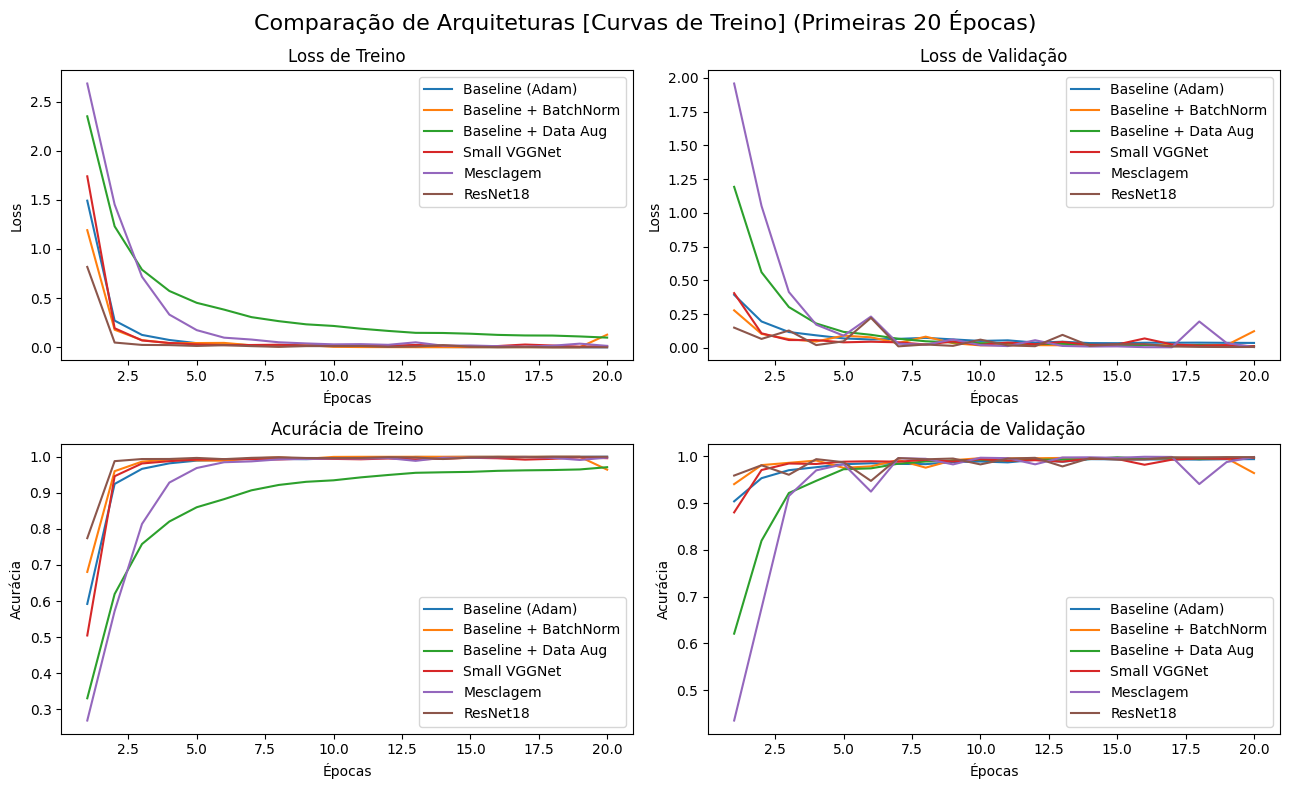

In [72]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Find the minimum length among all history lists
min_epochs_length = float('inf')
for name, r in metrics.items():
    if len(r["train_loss"]) < min_epochs_length:
        min_epochs_length = len(r["train_loss"])

epochs = range(1, min_epochs_length + 1)

colors = {
    "baseline_adam": "tab:blue",
    "baseline_bn": "tab:orange",
    "baseline_data_aug": "tab:green",
    "vgg": "tab:red",
    "mesclagem": "tab:purple",
    "resnet": "tab:brown"
}

labels = {
    "baseline_adam": "Baseline (Adam)",
    "baseline_bn": "Baseline + BatchNorm",
    "baseline_data_aug": "Baseline + Data Aug",
    "vgg": "Small VGGNet",
    "mesclagem": "Mesclagem",
    "resnet": "ResNet18"
}

for name, r in metrics.items():
    axes[0,0].plot(epochs, r["train_loss"][:min_epochs_length], label=labels[name], color=colors[name])
    axes[0,0].set_title("Loss de Treino")
    axes[0,0].set_xlabel("Épocas")
    axes[0,0].set_ylabel("Loss")
    axes[0,0].legend()

for name, r in metrics.items():
    axes[0,1].plot(epochs, r["val_loss"][:min_epochs_length], label=labels[name], color=colors[name])
    axes[0,1].set_title("Loss de Validação")
    axes[0,1].set_xlabel("Épocas")
    axes[0,1].set_ylabel("Loss")
    axes[0,1].legend()

for name, r in metrics.items():
    axes[1,0].plot(epochs, r["train_acc"][:min_epochs_length], label=labels[name], color=colors[name])
    axes[1,0].set_title("Acurácia de Treino")
    axes[1,0].set_xlabel("Épocas")
    axes[1,0].set_ylabel("Acurácia")
    axes[1,0].legend()

for name, r in metrics.items():
    axes[1,1].plot(epochs, r["val_acc"][:min_epochs_length], label=labels[name], color=colors[name])
    axes[1,1].set_title("Acurácia de Validação")
    axes[1,1].set_xlabel("Épocas")
    axes[1,1].set_ylabel("Acurácia")
    axes[1,1].legend()

plt.suptitle(f"Comparação de Arquiteturas [Curvas de Treino] (Primeiras {min_epochs_length} Épocas)", fontsize=16)
plt.tight_layout()
plt.savefig("figs/final_arch_comparation_graph.png", dpi=150, bbox_inches="tight")
plt.show()

### 13. Comparando Curvas de Treino


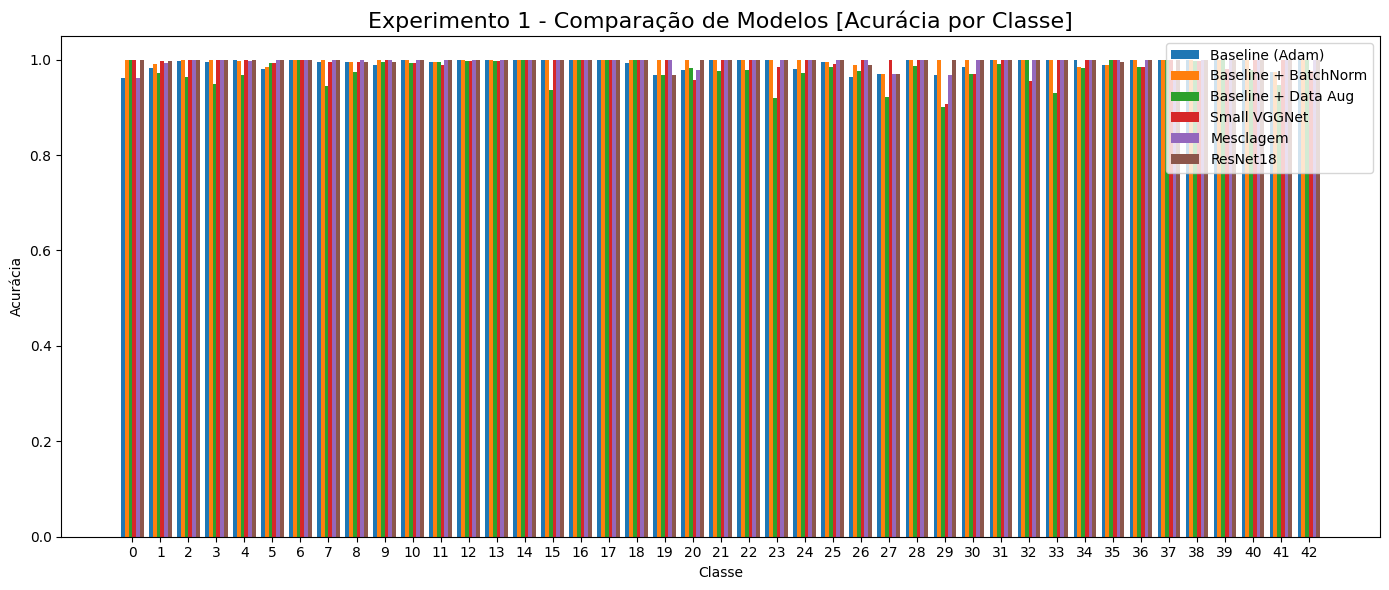

In [73]:
def plot_acc_by_class(metrics_results, num_classes, labels, colors, title, save_path=None):
    fig, ax = plt.subplots(figsize=(14, 6))

    n_series = len(metrics_results)
    width = 0.8 / n_series
    x = np.arange(num_classes)

    for i, (name, r) in enumerate(metrics_results.items()):
        offset = (i - (n_series - 1) / 2) * width
        ax.bar(
            x + offset,
            r["acc_per_class"],
            width=width,
            label=labels.get(name, name),
            color=colors.get(name, None)
        )

    ax.set_xlabel("Classe")
    ax.set_ylabel("Acurácia")
    ax.set_title(title, fontsize=16)
    ax.set_xticks(x)
    ax.legend()

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

labels = {
    "baseline_adam": "Baseline (Adam)",
    "baseline_bn": "Baseline + BatchNorm",
    "baseline_data_aug": "Baseline + Data Aug",
    "vgg": "Small VGGNet",
    "mesclagem": "Mesclagem",
    "resnet": "ResNet18"
}

colors = {
    "baseline_adam": "tab:blue",
    "baseline_bn": "tab:orange",
    "baseline_data_aug": "tab:green",
    "vgg": "tab:red",
    "mesclagem": "tab:purple",
    "resnet": "tab:brown"
}

plot_acc_by_class(
    metrics_results=metrics,
    num_classes=NUM_CLASSES,
    labels=labels,
    colors=colors,
    title="Experimento 1 - Comparação de Modelos [Acurácia por Classe]",
    save_path="figs/arch_comparation_acc_by_class.png"
)

### 14. Gerando Tabela de Acurácias

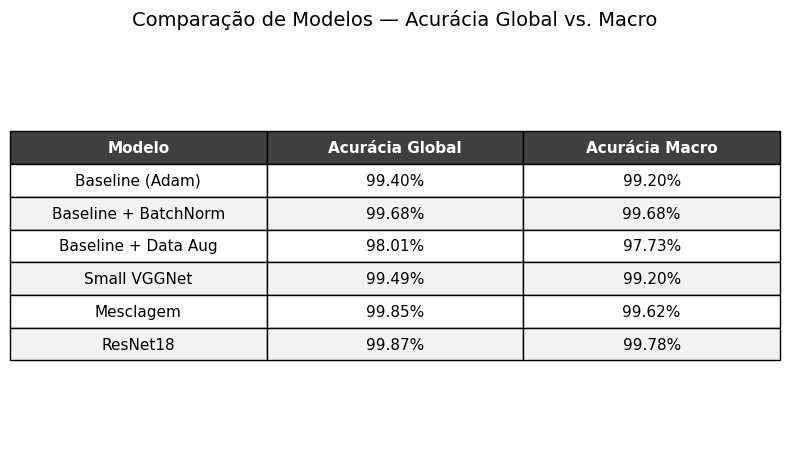

In [74]:
def plot_global_macro_table(metrics_results, labels, save_path=None):
    rows = []
    for name, r in metrics_results.items():
        rows.append([
            labels.get(name, name),
            f"{r['global_acc']*100:.2f}%",
            f"{r['macro_acc']*100:.2f}%"
        ])

    col_labels = ["Modelo", "Acurácia Global", "Acurácia Macro"]

    fig, ax = plt.subplots(figsize=(8, 0.6 * len(rows) + 1))
    ax.axis("off")

    table = ax.table(
        cellText=rows,
        colLabels=col_labels,
        cellLoc="center",
        loc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1, 1.8)

    # Negrito no cabeçalho
    for j in range(len(col_labels)):
        table[(0, j)].set_text_props(weight="bold", color="white")
        table[(0, j)].set_facecolor("#404040")

    # Zebra striping nas linhas
    for i in range(1, len(rows) + 1):
        color = "#f2f2f2" if i % 2 == 0 else "white"
        for j in range(len(col_labels)):
            table[(i, j)].set_facecolor(color)

    ax.set_title("Comparação de Modelos — Acurácia Global vs. Macro", fontsize=14, pad=20)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

plot_global_macro_table(
    metrics_results=metrics,
    labels=labels,
    save_path="figs/arch_comparation_acc_table.png"
)

### 15. Comparando Acurácia global e Macro Acurácia

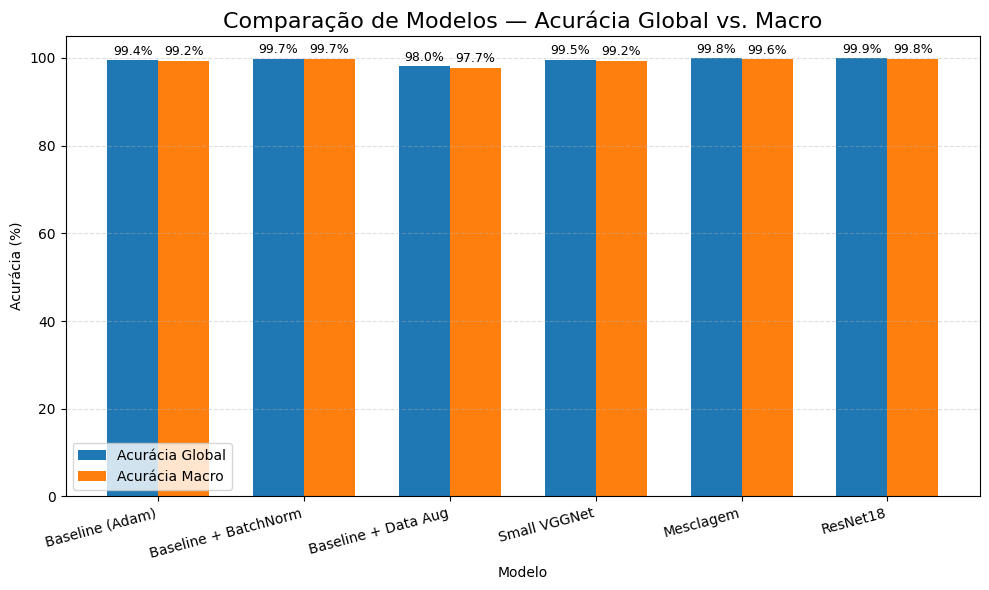

In [75]:
def plot_global_macro_bars(metrics_results, labels, save_path=None):
    names = list(metrics_results.keys())
    global_accs = [metrics_results[name]["global_acc"] * 100 for name in names]
    macro_accs = [metrics_results[name]["macro_acc"] * 100 for name in names]
    display_labels = [labels.get(name, name) for name in names]

    x = np.arange(len(names))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))

    bars1 = ax.bar(x - width/2, global_accs, width, label="Acurácia Global", color="tab:blue")
    bars2 = ax.bar(x + width/2, macro_accs, width, label="Acurácia Macro", color="tab:orange")

    ax.set_xlabel("Modelo")
    ax.set_ylabel("Acurácia (%)")
    ax.set_title("Comparação de Modelos — Acurácia Global vs. Macro", fontsize=16)
    ax.set_xticks(x)
    ax.set_xticklabels(display_labels, rotation=15, ha="right")
    ax.set_ylim(0, 105)
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    # valores no topo de cada barra
    for bars in (bars1, bars2):
        ax.bar_label(bars, fmt="%.1f%%", padding=2, fontsize=9)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

plot_global_macro_bars(
    metrics_results=metrics,
    labels=labels,
    save_path="figs/arch_comparation_global_macro_acc_bars.png"
)

### 16. Gerando .csv do melhor modelo

In [71]:
model = resnet
model.eval()
all_preds = []
with torch.no_grad():
    for images, _ in test_loader:
        outputs = model(images.to(device))
        all_preds.append(outputs.argmax(dim=1).cpu())
y_pred = torch.cat(all_preds)

# Gera o CSV para entrega — um por experimento
save_predictions(y_pred, "results/predicoes_baseline.csv", experiment_name="Baseline")
print(f"Predicoes salvas ({len(y_pred)} imagens)")

Predicoes salvas (12630 imagens)
